In [144]:
# @title
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):

    random.seed(seed)                     # Python random
    np.random.seed(seed)                  # NumPy random

    torch.manual_seed(seed)               # PyTorch CPU
    torch.cuda.manual_seed_all(seed)      # PyTorch GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [145]:
from pathlib import Path
import pandas as pd

fracture_file = Path("IR-Rail-Fracture-Data.csv")
master_files = [
    Path("RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx"),
    Path("RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx"),
    Path("RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx"),
]

for file_path in [fracture_file, *master_files]:
    print(f"{file_path.name}: {'FOUND' if file_path.exists() else 'MISSING'}")

df_NCR_PRYJ = pd.read_excel(master_files[0])
df_NCR_AGRA = pd.read_excel(master_files[1])
df_NCR_JHS = pd.read_excel(master_files[2])
df_master = pd.concat([df_NCR_AGRA, df_NCR_JHS, df_NCR_PRYJ], ignore_index=True)

df_fracture = pd.read_csv(fracture_file)

print("Master shape:", df_master.shape)
print("Fracture shape:", df_fracture.shape)

IR-Rail-Fracture-Data.csv: FOUND
RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx: FOUND
RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx: FOUND
RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx: FOUND
Master shape: (126969, 22)
Fracture shape: (12113, 24)


In [146]:
# @title
df_ncr = df_master[df_master["RLYCODE"].astype(str).str.strip().str.upper() == "NCR"]

print(df_ncr.shape)


(126969, 22)


In [147]:
df_ncr = df_ncr.drop(columns=['Unnamed: 17', 'KMTO', 'METTO', 'RAIL_LENGTH_IN_MET', 'RLYCODE', 'INSPDATE'])


In [148]:
df_ncr["CENSOR_DATE"] = pd.to_datetime('2025-08-01'
)

In [149]:
df_ncr.sample(5)

,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFD_CLASSIFICATION,CENSOR_DATE
11567,AGRA,DHO - BHA,DN,SEP-2021,60KG,65.160,130,215.0,RR,1332,398.70,22.90,SWR,1000,CURVE,OBSJP,2025-08-01
113435,PRYJ,PNK--ETW,UP,DEC-2021,60KG,88.110,130,223.0,RR,1055,420.40,22.32,LWR,1000,STRAIGHT,OBSJP,2025-08-01
100550,PRYJ,KRJ-GZB,IIIrd Line,FEB-2021,60KG,28.200,130,72.0,RR,1383,466.68,22.32,SWR,800,CURVE,OBSJP,2025-08-01
93795,PRYJ,ETW-SKB,UP,JAN-2020,60KG,65.440,130,353.0,RR,1189,20.94,22.32,LWR,1000,STRAIGHT,OBSJP,2025-08-01
119880,PRYJ,PRYJ-CNBI,UP,JUN-2023,60KG,45.961,130,95.0,LR,847,266.06,22.32,LWR,1000,STRAIGHT,OBSJP,2025-08-01


In [150]:
import pandas as pd

# ==========================================================
# CREATE DURATION FROM DATE_OF_LAYING TO CENSOR_DATE
# ==========================================================

# Convert DATE_OF_LAYING (e.g., 'FEB-2021') to datetime
df_ncr['DATE_OF_LAYING'] = pd.to_datetime(
    df_ncr['DATE_OF_LAYING'].astype(str).str.strip(),
    format='%b-%Y',
    errors='coerce'
)

# Convert CENSOR_DATE to datetime
df_ncr['CENSOR_DATE'] = pd.to_datetime(
    df_ncr['CENSOR_DATE'],
    errors='coerce'
)

# Duration in days (float)
df_ncr['DURATION'] = (
    (df_ncr['CENSOR_DATE'] - df_ncr['DATE_OF_LAYING'])
    .dt.total_seconds() / 86400.0
).astype(float)

# Remove invalid durations if needed
df_ncr = df_ncr[df_ncr['DURATION'] >= 0].copy()

print("\nDuration Statistics:")
print(df_ncr['DURATION'].describe())

print("\nSample:")
print(df_ncr[['DATE_OF_LAYING', 'CENSOR_DATE', 'DURATION']].head())


Duration Statistics:
count    125259.000000
mean       2269.632098
std        1829.222083
min           0.000000
25%         853.000000
50%        1765.000000
75%        3440.000000
max       22827.000000
Name: DURATION, dtype: float64

Sample:
  DATE_OF_LAYING CENSOR_DATE  DURATION
0     2017-02-01  2025-08-01    3103.0
1     2017-02-01  2025-08-01    3103.0
2     2017-02-01  2025-08-01    3103.0
3     2017-02-01  2025-08-01    3103.0
4     2024-09-01  2025-08-01     334.0


In [151]:
df_ncr = df_ncr[df_ncr.DURATION>0]

In [152]:
p75 = df_ncr['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df_ncr['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3469.0
25th Percentile: 884.0
Upper limit: 7346.5


In [153]:
df_ncr.DURATION.describe()

count    124206.000000
mean       2288.873702
std        1824.932614
min          31.000000
25%         884.000000
50%        1765.000000
75%        3469.000000
max       22827.000000
Name: DURATION, dtype: float64

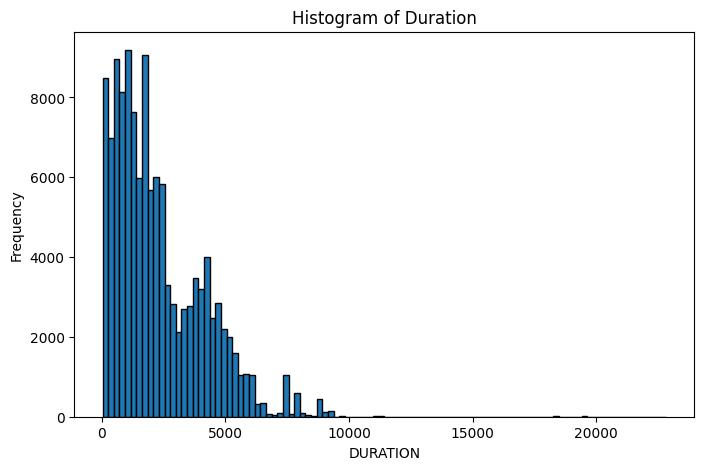

In [154]:
# @title
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df_ncr["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

Failure dataset

In [155]:
df_failure = pd.read_csv("IR-Rail-Fracture-Data.csv")

print(df_failure.shape)

(12113, 24)


In [156]:

# Filter NCR records
df_failure = df_failure[df_failure['RLYCODE'] == 'NCR']

print("Original Shape:", df_failure.shape)
print("NCR Shape:", df_ncr.shape)

# Optional: view first few rows
df_ncr.head()

Original Shape: (572, 24)
NCR Shape: (124206, 18)


,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFD_CLASSIFICATION,CENSOR_DATE,DURATION
0,AGRA,AF-AH,SL,2017-02-01,60KG,37.820,110,312.0,LR,0,0.00,22.9,SWR,800,STRAIGHT,OBSJP,2025-08-01,3103.0
1,AGRA,AF-AH,SL,2017-02-01,60KG,37.820,110,312.0,LR,0,3.23,22.9,SWR,800,CURVE,OBSJP,2025-08-01,3103.0
2,AGRA,AF-AH,SL,2017-02-01,60KG,37.820,110,312.0,LR,0,102.40,22.9,SWR,800,CURVE,OBSJP,2025-08-01,3103.0
3,AGRA,AF-AH,SL,2017-02-01,60KG,37.820,110,312.0,LR,0,108.70,22.9,SWR,800,CURVE,OBSJP,2025-08-01,3103.0
4,AGRA,AF-AH,SL,2024-09-01,60KG,38.008,110,44.0,LR,0,151.00,22.9,SWR,800,CURVE,OBSJP,2025-08-01,334.0


In [157]:
df_ncr.rename(
    columns={'USFD_CLASSIFICATION': 'USFDCLASSIFICATION'},
    inplace=True
)

In [158]:
df_failure["Weather_failed"] = 1
df_ncr["Weather_failed"] = 0


df_failure.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,FRACTURE_DATE,FRACTURE_TIME,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,ASSETTYPE,USFDCLASSIFICATION,USFDTESTDATE,LRRR,KM,METER,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,FRACTURE_DATE.1,LAYINGDATE.1,DURATION,Weather_failed
3760,NCR,AGRA,BTE-BKI,SL,2023-01-05-00.00.00,9:23,52KG,28.034,110,Sep-15,383.84,SEJ,GR,2023-01-04-00.00.00,RR,82,437,22.9,LWR,STRAIGHT,525,1/5/2023,9/1/2015,2683.0,1
7023,NCR,PRYJ,DDU-CAR,DN,2024-12-16-00.00.00,12:10,60KG,35.133,130,Mar-11,786.00,SEJ,GR,2024-11-14-00.00.00,RR,697,166,22.32,LWR,STRAIGHT,800,12/16/2024,3/1/2011,5039.0,1
3225,NCR,PRYJ,MKP LINK Jn,DN,2021-11-08-00.00.00,8:55,60KG,33.480,110,Jul-16,365.43,SEJ,GR,2021-09-14-00.00.00,LR,1260,73,22.32,LWR,STRAIGHT,800,11/8/2021,7/1/2016,1956.0,1
5463,NCR,PRYJ,PNK--ETW,DN,2022-11-18-00.00.00,5:59,60KG,76.940,130,May-11,685.15,SEJ,GR,2022-10-06-00.00.00,RR,1148,186,22.32,LWR,STRAIGHT,800,11/18/2022,5/1/2011,4219.0,1
7199,NCR,PRYJ,BRN ETH,SL,2020-01-17-00.00.00,9:40,52KG,2.800,75,Jan-06,567.15,SEJ,GR,2018-03-27-00.00.00,LR,46,653,22.32,LWR,STRAIGHT,350,1/17/2020,1/1/2006,5129.0,1


In [159]:
len(df_failure.SECTION.unique())

57

In [160]:
df_failure.DURATION.describe()

count      572.000000
mean      2857.561189
std       2115.288249
min       -441.000000
25%        926.750000
50%       3092.000000
75%       4182.250000
max      17919.000000
Name: DURATION, dtype: float64

In [161]:
df_failure.FRACTURE_DATE.max()

'2025-10-11-00.00.00'

In [162]:
df_failure.isnull().sum()

RLYCODE                0
DIVCODE                0
SECTION                0
LINE                   0
FRACTURE_DATE          0
FRACTURE_TIME          0
RAIL_SECTION           0
ANNUAL_GMT            21
SPEED                  0
LAYINGDATE             0
GMTCARRIED             5
ASSETTYPE              0
USFDCLASSIFICATION     0
USFDTESTDATE           0
LRRR                   0
KM                     0
METER                  0
AXLELOAD               0
TRACK_TYPE             0
STRAIGHT_CURVE         0
SERVICE_LIFE           0
FRACTURE_DATE.1        0
LAYINGDATE.1           0
DURATION               0
Weather_failed         0
dtype: int64

In [163]:
df_ncr.columns

Index(['DIVCODE', 'SECTION', 'LINE', 'DATE_OF_LAYING', 'RAIL_SECTION',
       'ANNUAL_GMT', 'SPEED', 'GMTCARRIED', 'LRRR', 'KMFROM', 'METFROM',
       'AXLELOAD', 'TRACK_TYPE', 'SERVICE_LIFE', 'STRAIGHT_CURVE',
       'USFDCLASSIFICATION', 'CENSOR_DATE', 'DURATION', 'Weather_failed'],
      dtype='object')

In [164]:
df_failure.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'FRACTURE_DATE',
       'FRACTURE_TIME', 'RAIL_SECTION', 'ANNUAL_GMT', 'SPEED', 'LAYINGDATE',
       'GMTCARRIED', 'ASSETTYPE', 'USFDCLASSIFICATION', 'USFDTESTDATE', 'LRRR',
       'KM', 'METER', 'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE',
       'SERVICE_LIFE', 'FRACTURE_DATE.1', 'LAYINGDATE.1', 'DURATION',
       'Weather_failed'],
      dtype='object')

In [165]:
df_failure.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,FRACTURE_DATE,FRACTURE_TIME,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,ASSETTYPE,USFDCLASSIFICATION,USFDTESTDATE,LRRR,KM,METER,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,FRACTURE_DATE.1,LAYINGDATE.1,DURATION,Weather_failed
600,NCR,AGRA,MTJ-OKA,UP,2018-07-13-00.00.00,11:35,60KG,65.26,160,Jul-18,473.00,SEJ,GR,2018-06-15-00.00.00,LR,1440,191,22.9,LWR,STRAIGHT,800,7/13/2018,7/1/2018,12.0,1
5205,NCR,AGRA,JAB -ETUE,DN,2017-01-01-00.00.00,8:30,52KG,16.00,110,Dec-05,140.21,RAIL,GR,2016-12-21-00.00.00,RR,1257,231,22.9,LWR,STRAIGHT,525,1/1/2017,12/1/2005,4049.0,1
3458,NCR,PRYJ,CAR - COI,UP,2018-11-08-00.00.00,7:05,60KG,94.64,130,Aug-12,604.44,LWR,GR,2018-10-13-00.00.00,LR,770,930,22.32,LWR,STRAIGHT,800,11/8/2018,8/1/2012,2290.0,1
3717,NCR,PRYJ,ETW-SKB,UP,2017-10-16-00.00.00,9:35,60KG,79.44,130,Aug-10,733.74,RAIL,GR,2017-09-27-00.00.00,RR,1211,512,22.32,SWR,CURVE,800,10/16/2017,8/1/2010,2633.0,1
5352,NCR,PRYJ,CPN-GOY,OML,2019-04-08-00.00.00,7:48,60KG,NaN,50,Dec-07,200.00,SEJ,GR,2018-12-08-00.00.00,RR,1019,167,22.32,SWR,STRAIGHT,800,4/8/2019,12/1/2007,4146.0,1


In [166]:

df = pd.concat([df_ncr, df_failure], ignore_index=True)

print(df.shape)
df.sample(5)

(124778, 29)


,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFDCLASSIFICATION,CENSOR_DATE,DURATION,Weather_failed,RLYCODE,FRACTURE_DATE,FRACTURE_TIME,LAYINGDATE,ASSETTYPE,USFDTESTDATE,KM,METER,FRACTURE_DATE.1,LAYINGDATE.1
12645,AGRA,DHO - BHA,UP,2015-08-01,60KG,48.030,130,476.0,RR,1296.0,23.10,22.9,LWR,1000,STRAIGHT,OBSJP,2025-08-01,3653.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78439,PRYJ,BRN-HRS,UP,2024-02-01,60KG,39.532,130,69.0,RR,1278.0,941.00,22.32,LWR,800,STRAIGHT,OBSJP,2025-08-01,547.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68987,JHS,LAR-KURJ,SL,2022-11-01,60KG,10.630,70,44.0,RR,1068.0,756.00,22.32,LWR,800,STRAIGHT,OBSJP,2025-08-01,1004.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118399,PRYJ,PRYJ-CNBI,UP,2024-12-01,60KG,29.406,130,27.0,LR,965.0,153.00,22.32,SWR,800,STRAIGHT,OBSJP,2025-08-01,243.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86146,PRYJ,CNBI CNB,DN,2023-02-01,60KG,21.116,50,58.0,RR,1018.0,40.61,22.32,LWR,800,CURVE,OBSJP,2025-08-01,912.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


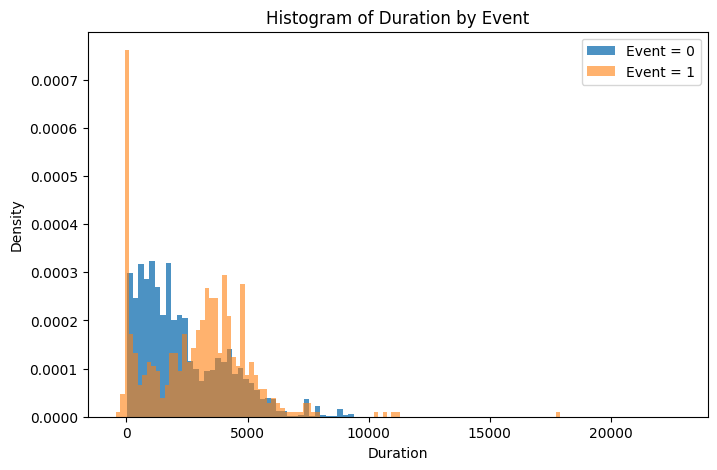

In [167]:
# @title
plt.figure(figsize=(8,5))

plt.hist(df[df["Weather_failed"] == 0]["DURATION"],
         bins=100, alpha=0.8, density=True, label="Event = 0")

plt.hist(df[df["Weather_failed"] == 1]["DURATION"],
         bins=100, alpha=0.6, density=True, label="Event = 1")

plt.xlabel("Duration")
plt.ylabel("Density")
plt.title("Histogram of Duration by Event")
plt.legend()
plt.show()



In [168]:
len(df)

124778

In [169]:
df[df.DIVCODE == "AGRA"].SECTION.unique()

array(['AF-AH', 'AGC-BKI connectivity line', 'AGC-IDH', 'AGC-RKM',
       'AH-BTE', 'BHA-AGC', 'BHA-UDMR', 'BLNR - DHO', 'BTE-BKI',
       'BTE-MTJ', 'CIK-PRK Connectivity line', 'DHO - BHA',
       'ETUE (W)-MTI', 'ETUE-TDL', 'GWL - ETW', 'JAB -ETUE',
       'JAB(W line AF) -BXN', 'MTJ-AH', 'MTJ-AWR', 'MTJ-OKA', 'RKM-MTJ',
       'RKM-STRB', 'STRB-JAB'], dtype=object)

In [170]:
# @title
p75 = df['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5 *(p75-p25)
print("Upper limit:", p75 + iqr)


75th Percentile: 3469.0
25th Percentile: 884.0
Upper limit: 7346.5


In [171]:
upper = p75 + iqr
df = df[df.DURATION <= upper]

In [172]:
df['DURATION'].quantile(0.95)

5236.0

In [173]:
df.DURATION.describe()

count    122092.000000
mean       2160.778454
std        1601.481569
min        -441.000000
25%         853.000000
50%        1734.000000
75%        3287.000000
max        7344.000000
Name: DURATION, dtype: float64

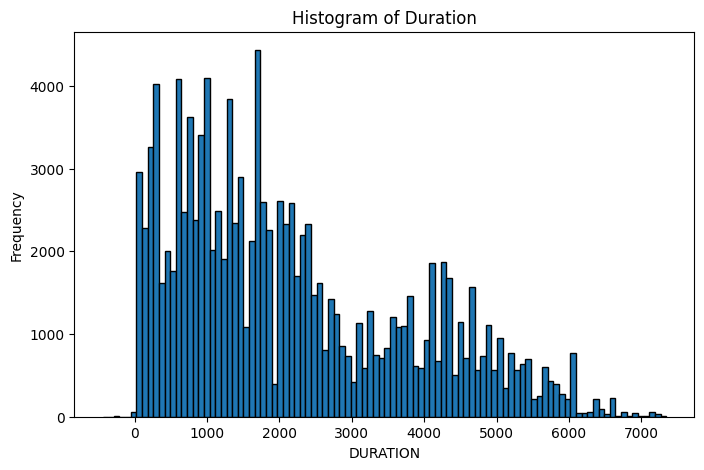

In [174]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [175]:
df.Weather_failed.value_counts()

Weather_failed
0    121531
1       561
Name: count, dtype: int64

In [176]:
df['SECTION'].value_counts()

SECTION
PRYJ-CNBI                9160
MTJ-OKA                  8689
KRJ-GZB                  6795
PNK--ETW                 5554
CAR - COI                5412
                         ... 
Link Jn COI                48
BNPR - OHAN                46
HRS HRF                    17
GWL SOE                    12
AGD - MAKR Chord line       8
Name: count, Length: 77, dtype: int64

In [177]:
df['LINE'].value_counts()

LINE
DN            40550
UP            38987
SL            30315
IIIrd Line     9008
IVth Line      2335
OML             375
N               260
S               254
Chord Line        8
Name: count, dtype: int64

In [178]:
# @title
def reduce_line(line):
    if line in ["DN","DN 1", "DN 2"]:
        return "DN"
    elif line in ["SL", "IIIrd Line", "IVth Line", "MID"]:
        return "SL"
    elif line in ["UP 1", "UP 2","UP"]:
        return "UP"
    else:
        return "OT"

df["LINE"] = df["LINE"].apply(reduce_line)
df["LINE"].value_counts()


LINE
SL    41658
DN    40550
UP    38987
OT      897
Name: count, dtype: int64

In [179]:
df =df[df['RAIL_SECTION']!= 'OTHER']

In [180]:
df.RAIL_SECTION.value_counts()

RAIL_SECTION
60KG    101722
52KG     20331
Name: count, dtype: int64

In [181]:
df['USFDCLASSIFICATION'].value_counts()

USFDCLASSIFICATION
OBSJP                121113
GR                      538
OBS                     380
OBS Joggled Plate        22
Name: count, dtype: int64

In [182]:
# @title

#Replace values to standardize categories
df['USFDCLASSIFICATION'] = df['USFDCLASSIFICATION'].replace({
    
    'OBS Joggled Plate': 'OBS',
    'OBSJP': 'OBS'


})


In [183]:
df['USFDCLASSIFICATION'].value_counts()

USFDCLASSIFICATION
OBS    121515
GR        538
Name: count, dtype: int64

In [184]:
df['USFDCLASSIFICATION'].unique()

array(['OBS', 'GR'], dtype=object)

In [185]:
# @title
import numpy as np
import re

def clean_axle_load(x):
    if pd.isna(x):
        return np.nan

    # Convert to string
    x = str(x).strip()

    # Handle ranges like "Up to 20.32"
    if "up to" in x.lower():
        num = re.findall(r"\d+\.?\d*", x)
        return int(round(float(num[0]))) if num else np.nan

    # Extract numeric part
    num = re.findall(r"\d+\.?\d*", x)
    if num:
        return int(round(float(num[0])))

    return np.nan


df["AXLELOAD"] = df["AXLELOAD"].apply(clean_axle_load)

df['AXLELOAD'].value_counts()

AXLELOAD
22    81899
23    40154
Name: count, dtype: int64

In [186]:

df['RAIL_SECTION'] = df['RAIL_SECTION'].str.replace('KG', '', regex=False).astype(int)

In [187]:
df['RAIL_SECTION'].value_counts()

RAIL_SECTION
60    101722
52     20331
Name: count, dtype: int64

Encoding

In [188]:
# @title
import numpy as np

# NUMPY-SKLEARN COMPATIBILITY PATCH
# Some older versions of sklearn expect np.long / np.ulong to exist.
# Define them if missing before importing sklearn-related utilities.
if not hasattr(np, "long"):
	np.long = np.int64
if not hasattr(np, "ulong"):
	np.ulong = np.uint64

import torch
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify all object dtype columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['DIVCODE', 'SECTION', 'LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'USFDCLASSIFICATION', 'RLYCODE', 'FRACTURE_DATE', 'FRACTURE_TIME', 'LAYINGDATE', 'ASSETTYPE', 'USFDTESTDATE', 'FRACTURE_DATE.1', 'LAYINGDATE.1']


In [189]:
p95 = df['DURATION'].quantile(0.99)
print("95th Percentile:", p95)

95th Percentile: 6056.0


In [190]:
pd.set_option('display.max_columns', None)
df.isnull().sum().to_frame('Null Count').T

,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFDCLASSIFICATION,CENSOR_DATE,DURATION,Weather_failed,RLYCODE,FRACTURE_DATE,FRACTURE_TIME,LAYINGDATE,ASSETTYPE,USFDTESTDATE,KM,METER,FRACTURE_DATE.1,LAYINGDATE.1
Null Count,0,0,0,560,0,21,0,5,0,560,560,0,0,0,0,0,560,0,0,121493,121493,121493,121493,121493,121493,121493,121493,121493,121493


***Modeling***

In [191]:
!pip install torchtuples
import torch # For building the networks
import torchtuples as tt # Some useful functions


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [192]:
df

,DIVCODE,SECTION,LINE,DATE_OF_LAYING,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFDCLASSIFICATION,CENSOR_DATE,DURATION,Weather_failed,RLYCODE,FRACTURE_DATE,FRACTURE_TIME,LAYINGDATE,ASSETTYPE,USFDTESTDATE,KM,METER,FRACTURE_DATE.1,LAYINGDATE.1
0,AGRA,AF-AH,SL,2017-02-01,60,37.820,110,312.00,LR,0.0,0.00,23,SWR,800,STRAIGHT,OBS,2025-08-01,3103.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGRA,AF-AH,SL,2017-02-01,60,37.820,110,312.00,LR,0.0,3.23,23,SWR,800,CURVE,OBS,2025-08-01,3103.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGRA,AF-AH,SL,2017-02-01,60,37.820,110,312.00,LR,0.0,102.40,23,SWR,800,CURVE,OBS,2025-08-01,3103.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGRA,AF-AH,SL,2017-02-01,60,37.820,110,312.00,LR,0.0,108.70,23,SWR,800,CURVE,OBS,2025-08-01,3103.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGRA,AF-AH,SL,2024-09-01,60,38.008,110,44.00,LR,0.0,151.00,23,SWR,800,CURVE,OBS,2025-08-01,334.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124762,JHS,AIT BZM,DN,NaT,52,12.640,110,374.62,RR,NaN,NaN,22,LWR,525,STRAIGHT,GR,NaT,6857.0,1,NCR,2017-01-08-00.00.00,3:10,Apr-98,RAIL,2016-12-13-00.00.00,1289.0,13.0,1/8/2017,4/1/1998
124763,JHS,AIT BZM,DN,NaT,52,12.640,110,366.05,RR,NaN,NaN,22,LWR,525,STRAIGHT,GR,NaT,6916.0,1,NCR,2018-01-08-00.00.00,1:30,Feb-99,RAIL,2017-11-13-00.00.00,1243.0,422.0,1/8/2018,2/1/1999
124764,JHS,AIT BZM,DN,NaT,52,12.640,110,370.14,LR,NaN,NaN,22,LWR,525,STRAIGHT,GR,NaT,7175.0,1,NCR,2017-11-22-00.00.00,5:50,Apr-98,RAIL,2017-09-07-00.00.00,1289.0,12.0,11/22/2017,4/1/1998
124765,JHS,AIT BZM,DN,NaT,52,19.680,110,366.91,RR,NaN,NaN,22,LWR,525,STRAIGHT,GR,NaT,7308.0,1,NCR,2019-01-04-00.00.00,5:50,Jan-99,SEJ,2019-01-01-00.00.00,1240.0,180.0,1/4/2019,1/1/1999


In [193]:
df.drop(columns=['FRACTURE_DATE.1', 'LAYINGDATE.1', 'RLYCODE', 'CENSOR_DATE', 'DATE_OF_LAYING', 'FRACTURE_DATE',], inplace=True)

In [194]:
# @title
df['NEW_GMT'] = (df['DURATION']/365)*df['ANNUAL_GMT']
rail_map = { 52: 1,60: 2}
df["RAIL_SECTION"] = df["RAIL_SECTION"].map(rail_map)

# df["GMT_NO"] = df["GMT_CARRIED"] /df["ANNUAL_GMT"]
df["ANNUAL_LOAD"] = df["ANNUAL_GMT"] * df["AXLELOAD"]
df["AXLELOAD"]  = df["AXLELOAD"].map({22: 1, 23:2})
df["SPEED_AGMT"] = df["SPEED"] * df["ANNUAL_GMT"]


In [195]:
df.drop(columns=['LAYINGDATE', 'METER', 'USFDTESTDATE', 'KM'], inplace=True)

In [196]:
df = df.drop(columns=['ANNUAL_GMT'])
df

,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,KMFROM,METFROM,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFDCLASSIFICATION,DURATION,Weather_failed,FRACTURE_TIME,ASSETTYPE,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT
0,AGRA,AF-AH,SL,2,110,312.00,LR,0.0,0.00,2,SWR,800,STRAIGHT,OBS,3103.0,0,NaN,NaN,321.521808,869.860,4160.20
1,AGRA,AF-AH,SL,2,110,312.00,LR,0.0,3.23,2,SWR,800,CURVE,OBS,3103.0,0,NaN,NaN,321.521808,869.860,4160.20
2,AGRA,AF-AH,SL,2,110,312.00,LR,0.0,102.40,2,SWR,800,CURVE,OBS,3103.0,0,NaN,NaN,321.521808,869.860,4160.20
3,AGRA,AF-AH,SL,2,110,312.00,LR,0.0,108.70,2,SWR,800,CURVE,OBS,3103.0,0,NaN,NaN,321.521808,869.860,4160.20
4,AGRA,AF-AH,SL,2,110,44.00,LR,0.0,151.00,2,SWR,800,CURVE,OBS,334.0,0,NaN,NaN,34.779923,874.184,4180.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124762,JHS,AIT BZM,DN,1,110,374.62,RR,NaN,NaN,1,LWR,525,STRAIGHT,GR,6857.0,1,3:10,RAIL,237.458849,278.080,1390.40
124763,JHS,AIT BZM,DN,1,110,366.05,RR,NaN,NaN,1,LWR,525,STRAIGHT,GR,6916.0,1,1:30,RAIL,239.502027,278.080,1390.40
124764,JHS,AIT BZM,DN,1,110,370.14,LR,NaN,NaN,1,LWR,525,STRAIGHT,GR,7175.0,1,5:50,RAIL,248.471233,278.080,1390.40
124765,JHS,AIT BZM,DN,1,110,366.91,RR,NaN,NaN,1,LWR,525,STRAIGHT,GR,7308.0,1,5:50,SEJ,394.031342,432.960,2164.80


In [197]:
df = df.drop(columns=['FRACTURE_TIME'])


In [198]:
df = df.drop(columns=['ASSETTYPE'])


In [199]:

df= df[df.DURATION >0]

In [201]:
df.drop(columns=['KMFROM', 'METFROM'], inplace=True)

In [203]:
df.dropna(inplace=True)

In [204]:
df.isnull().sum()

DIVCODE               0
SECTION               0
LINE                  0
RAIL_SECTION          0
SPEED                 0
GMTCARRIED            0
LRRR                  0
AXLELOAD              0
TRACK_TYPE            0
SERVICE_LIFE          0
STRAIGHT_CURVE        0
USFDCLASSIFICATION    0
DURATION              0
Weather_failed        0
NEW_GMT               0
ANNUAL_LOAD           0
SPEED_AGMT            0
dtype: int64

In [205]:
# ==========================================================
# NUMPY PATCH
# ==========================================================

import numpy as np

if not hasattr(np, "long"):
    np.long = np.int64

if not hasattr(np, "ulong"):
    np.ulong = np.uint64

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.30,
    stratify=df["Weather_failed"],
    random_state=42
)

print(df_train.shape)
print(df_test.shape)

(85416, 17)
(36608, 17)


In [206]:

import numpy as np

# Patch for older sklearn versions expecting np.long
if not hasattr(np, "long"):
    np.long = np.int64

from sklearn.model_selection import train_test_split

# ==========================================================
# TRAIN-TEST SPLIT
# ==========================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.30,
    stratify=df['Weather_failed'],
    random_state=42
)

print("Train Shape :", df_train.shape)
print("Test Shape  :", df_test.shape)

print("Train events:", df_train['Weather_failed'].sum())
print("Test events :", df_test['Weather_failed'].sum())

Train Shape : (85416, 17)
Test Shape  : (36608, 17)
Train events: 372
Test events : 159


In [207]:
from pycox.models import PCHazard
from pycox.evaluation import EvalSurv

In [208]:
df_train

,DIVCODE,SECTION,LINE,RAIL_SECTION,SPEED,GMTCARRIED,LRRR,AXLELOAD,TRACK_TYPE,SERVICE_LIFE,STRAIGHT_CURVE,USFDCLASSIFICATION,DURATION,Weather_failed,NEW_GMT,ANNUAL_LOAD,SPEED_AGMT
103968,PRYJ,MKP LINK Jn,UP,2,110,280.0,RR,1,SWR,800,STRAIGHT,OBS,3287.0,0,233.061808,569.360,2846.80
123319,PRYJ,SKB-TDL,UP,2,130,47.0,RR,1,SWR,800,STRAIGHT,OBS,334.0,0,36.779348,884.246,5225.09
46410,JHS,GWL - ETW,SL,2,80,100.0,LR,2,LWR,800,CURVE,OBS,4961.0,0,102.753863,173.880,604.80
62618,JHS,KID OHAN,SL,1,100,169.0,RR,1,SWR,525,STRAIGHT,OBS,2496.0,0,157.282192,506.000,2300.00
109358,PRYJ,PNK--ETW,SL,2,130,26.0,RR,1,FP/SR,800,STRAIGHT,OBS,731.0,0,22.080205,242.550,1433.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22203,AGRA,MTJ-AWR,SL,2,110,49.0,RR,2,SWR,800,STRAIGHT,OBS,731.0,0,13.045847,149.822,716.54
85462,PRYJ,CNB GOY,SL,2,50,16.0,RR,1,SWR,800,STRAIGHT,OBS,639.0,0,12.984830,163.174,370.85
17986,AGRA,JAB(W line AF) -BXN,SL,1,110,62.0,RR,2,FP/SR,525,STRAIGHT,OBS,762.0,0,54.026844,595.217,2846.69
122016,PRYJ,SKB-TDL,DN,2,130,257.0,LR,1,SWR,1000,STRAIGHT,OBS,1583.0,0,333.687726,1692.680,10002.20


In [209]:
df_train["Weather_failed"].value_counts()

Weather_failed
0    85044
1      372
Name: count, dtype: int64

In [210]:
# @title
from category_encoders.binary import BinaryEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

cols_standardize = ['NEW_GMT', 'ANNUAL_LOAD', 'SPEED_AGMT', 'GMTCARRIED']   #, 'SPEED_AXLE'
ordinal_cols = ["USFDCLASSIFICATION"]
order = [["GR", "OBS"]]
object_cols = df_train.select_dtypes(include="object").columns.tolist()
binary_cols = ['SECTION']

# Remove ordinal column from one-hot encoding
object_cols = [col for col in object_cols if col not in ordinal_cols and col not in binary_cols]

cols_leave = [
    c for c in df_train.columns
    if c not in cols_standardize
    and c not in ordinal_cols
    and c not in object_cols
    and c not in binary_cols
    and c not in ['Weather_failed', 'DURATION']  #,
]

x_mapper = ColumnTransformer(
    transformers=[
        ('standardize', StandardScaler(), cols_standardize),
        ('binary', BinaryEncoder(drop_invariant=False), binary_cols),
        ('ordinal', OrdinalEncoder(categories=order, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('onehot', OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False), object_cols),
        ('leave', 'passthrough', cols_leave)
    ]
)

# --- Fit on training and transform all datasets ---
x_train_transformed = x_mapper.fit_transform(df_train)
x_test_transformed = x_mapper.transform(df_test)

# Convert to dense array if sparse, then to float32
x_train = np.asarray(x_train_transformed).astype('float32')
x_test = np.asarray(x_test_transformed).astype('float32')

In [211]:
# @title
feature_names = x_mapper.get_feature_names_out()
GMT_INDEX = list(feature_names).index("standardize__GMTCARRIED")

print("GMT_INDEX:", GMT_INDEX)

GMT_INDEX: 3


In [212]:
# @title
GMT_INDEX = 3
print("GMT_INDEX:", GMT_INDEX)
print("Raw GMT values (scaled):", x_train[:5, GMT_INDEX])
print("GMT std:", x_train[:, GMT_INDEX].std())

GMT_INDEX: 3
Raw GMT values (scaled): [ 0.1811822  -0.8576799  -0.6213722  -0.31372634 -0.95131123]
GMT std: 1.0



**Descretization**


In [213]:
df.Weather_failed.unique()

array([0, 1], dtype=int64)

In [214]:
num_durations = 100
labtrans = PCHazard.label_transform(num_durations)


get_target = lambda df: (df['DURATION'].values, df['Weather_failed'].values)
y_train = labtrans.fit_transform(*get_target(df_train))
durations_test, events_test = get_target(df_test)
durations_train, events_train = get_target(df_train)


In [215]:
# df_test['Duration'] =  y_pred
df_test.DURATION.describe()

count    36608.000000
mean      2164.592248
std       1602.161302
min          3.000000
25%        884.000000
50%       1734.000000
75%       3287.000000
max       7336.000000
Name: DURATION, dtype: float64

In [216]:
# @title
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

In [217]:
# @title

def nll_pc_hazard_loss(
    phi,
    idx_durations,
    events,
    interval_frac,
    gamma=2,
    reduction="none"
):
    """
    PC-Hazard NLL with focal weighting on event term
    """
    if events.dtype is torch.bool:
        events = events.float()

    idx_durations = idx_durations.view(-1, 1)
    events = events.view(-1)
    interval_frac = interval_frac.view(-1)

    # Keep valid samples
    keep = idx_durations.view(-1) >= 0
    phi = phi[keep]
    idx_durations = idx_durations[keep]
    events = events[keep]
    interval_frac = interval_frac[keep]

    # Hazard
    haz = torch.nn.functional.softplus(phi)

    # Event hazard
    h_e = haz.gather(1, idx_durations).view(-1)
    h_e = torch.clamp(h_e, min=1e-5, max=1.0)
    # ----- FOCAL EVENT TERM -----
    focal_weight = (1.0 - h_e).pow(gamma)
    log_h_e = torch.log(h_e + 1e-8) * events * focal_weight

    # ----- Survival term -----
    scaled_h_e = h_e * interval_frac
    haz_padded = torch.nn.functional.pad(haz, (1, 0))
    cum_haz = haz_padded.cumsum(1).gather(1, idx_durations).view(-1)

    loss = -log_h_e + scaled_h_e + cum_haz

    if reduction == "mean":
        return loss.mean()
    elif reduction == "sum":
        return loss.sum()
    return loss


In [218]:
class Hazard(nn.Module):
    def __init__(self, in_features, num_intervals):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        self.hazard_head = nn.Linear(64, num_intervals)

    def forward(self, x):
        z = self.encoder(x)
        phi = self.hazard_head(z)
        return phi


In [219]:
def predict_survival(phi):
    haz = F.softplus(phi)
    cum_haz = haz.cumsum(dim=1)
    surv = torch.exp(-cum_haz)
    return surv

In [220]:
# @title
def monotonic_gmt_penalty(phi, x, gmt_index):

    haz = torch.nn.functional.softplus(phi)

    # take gradient w.r.t. full input
    grad_x = torch.autograd.grad(
        outputs=haz.sum(),
        inputs=x,
        create_graph=True,
        allow_unused=True
    )[0]

    if grad_x is None:
        return torch.tensor(0.0, device=x.device)

    grad_gmt = grad_x[:, gmt_index]



    return torch.relu(-grad_gmt).mean()

def gmt_slope_smoothness_penalty(phi, x, gmt_index, eps=1e-3):

    haz = torch.nn.functional.softplus(phi)

    grad_x = torch.autograd.grad(
        outputs=haz.sum(),
        inputs=x,
        create_graph=True
    )[0]

    gmt = x[:, gmt_index]
    grad_gmt = grad_x[:, gmt_index]

    # sort by GMT
    idx = torch.argsort(gmt)
    g = grad_gmt[idx]

    g_prev = g[:-1]
    g_curr = g[1:]

    return torch.relu(g_prev - g_curr + eps).mean()


In [221]:
# @title
def survival_quantile(surv, time_grid, tau):

    target = 1 - tau
    crossed = surv <= target
    has = crossed.any(dim=1)

    idx = torch.zeros(surv.size(0), dtype=torch.long, device=surv.device)
    idx[has] = crossed[has].float().argmax(dim=1)

    q = time_grid[idx]
    return q


def censored_pinball_loss(q_pred, durations, events, tau):
    diff = durations - q_pred

    loss_fail = torch.maximum(tau * diff, (tau - 1) * diff)
    loss_cens = (1 - tau) * torch.relu(q_pred - durations)

    loss = events * loss_fail + (1 - events) * loss_cens
    return loss.mean()


In [222]:
# @title
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
time_grid = torch.linspace(
    0,
    durations_train.max(),
    num_durations
).to(device)

Using device: cpu


In [223]:
def train_model(
    model,
    x,
    durations,
    events,
    idx_durations,
    interval_frac,
    epochs=5000,
    lr=5e-3,
    patience=40,
    min_delta=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = float("inf")
    best_surv = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Enable gradients for monotonic constraint
        x_in = x.detach().clone().requires_grad_(True)

        # ---------- Forward ----------
        phi = model(x_in)

        # ---------- PC-Hazard loss ----------
        loss_surv = nll_pc_hazard_loss(
            phi, idx_durations, events, interval_frac
        )

        # # ---------- Monotonic GMT penalty ----------
        loss_mono = monotonic_gmt_penalty(
            phi, x_in, GMT_INDEX
        )
        loss_smooth = gmt_slope_smoothness_penalty(phi, x_in, GMT_INDEX)
        # survival
        haz = torch.nn.functional.softplus(phi)
        cum_haz = torch.cumsum(haz, dim=1)
        surv = torch.exp(-cum_haz)

        # quantile prediction
        q_tau = survival_quantile(surv, time_grid, tau=0.5)

        # pinball loss
        loss_q = censored_pinball_loss(q_tau, durations, events, tau=0.5)

        # ---------- Total loss ----------

        w_fail = 18   # strong amplification
        w_cens = 1

        if (events == 1).sum() > 0:
            loss_surv = (
                w_fail * loss_surv[events == 1].mean()
            + w_cens * loss_surv[events == 0].mean()
            )
        else:
            loss_surv = loss_surv.mean()

        loss =   0.6*loss_surv + 20*loss_mono + 0.01*loss_q + 0.1*loss_smooth

        # ---------- NaN guard ----------
        if torch.isnan(loss) or torch.isinf(loss):

            optimizer.zero_grad()
            continue



        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        # ---------- Early stopping logic ----------
        improved = loss.item() < best_loss - min_delta

        if improved:
            best_loss = loss.item()
            wait = 0

            # Save best-survival model
            if loss.item() < best_surv:
                best_surv = loss.item()
                best_state = {
                    k: v.detach().clone()
                    for k, v in model.state_dict().items()
                }
        else:
            wait += 1

        # ---------- Logging ----------
        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Surv: {loss_surv.item():.4f} | "
                f"pinball: {loss_q.item():.4f} | "
                f"Mono: {loss_mono.item():.4f} | "
                f"Mono: {loss_smooth.item():.4f} | "
                f"Total: {loss.item():.4f}"

             )

        # ---------- Stop ----------
        if wait >= patience:
            print(
                f"\nEarly stopping at epoch {epoch} "
                f"(best total loss = {best_loss:.4f})"
            )
            break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Training finished. Best survival loss = {best_surv:.4f}")



In [224]:
y_train

(array([44,  4, 67, ..., 10, 21, 58], dtype=int64),
 array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 array([0.7576253 , 0.5479303 , 0.5517429 , ..., 0.375817  , 0.5550109 ,
        0.85076255], dtype=float32))

In [225]:
# @title
def predict_median(surv, time_grid):

    N, T = surv.shape
    out = torch.zeros(N, device=surv.device)

    for i in range(N):
        s = surv[i]
        # find first index where S <= 0.5
        idx = torch.where(s <= 0.5)[0]

        if len(idx) == 0:
            out[i] = time_grid[-1]
        else:
            k = idx[0].item()

            if k == 0:
                out[i] = time_grid[0]
            else:
                t1, t2 = time_grid[k-1], time_grid[k]
                s1, s2 = s[k-1], s[k]

                # linear interpolation
                out[i] = t1 + (0.5 - s1) * (t2 - t1) / (s2 - s1)

    return out

tau =df_train['DURATION'].quantile(0.95)

def predict_rmst_tau(surv, time_grid, tau):

    mask = time_grid <= tau

    rmst = torch.trapezoid(
        surv[:, mask],
        time_grid[mask],
        dim=1
    )

    return rmst.detach().cpu().numpy()


In [226]:
# @title
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
x_train = torch.tensor(x_train, dtype=torch.float32).to(device)

durations_train = torch.tensor(durations_train, dtype=torch.float32).to(device)
events_train = torch.tensor(events_train, dtype=torch.float32).to(device)

idx_durations_train = torch.tensor(y_train[0], dtype=torch.long).to(device)
interval_frac_train = torch.tensor(y_train[2], dtype=torch.float32).to(device)

model = Hazard(
    in_features=x_train.shape[1],
    num_intervals=num_durations
).to(device)

train_model(
    model,
    x_train,
    durations_train,
    events_train,
    idx_durations_train,
    interval_frac_train,
    epochs=1000
)

Epoch 000 | Surv: 520.5372 | pinball: 6.1507 | Mono: 0.0091 | Mono: 0.0134 | Total: 312.5664
Epoch 010 | Surv: 109.6172 | pinball: 22.8727 | Mono: 0.1038 | Mono: 0.1508 | Total: 68.0910
Epoch 020 | Surv: 71.1108 | pinball: 187.8875 | Mono: 0.0173 | Mono: 0.0257 | Total: 44.8941


In [ ]:
# @title
print(f"x_train device: {x_train.device}")
print(f"Model device: {next(model.parameters()).device}")

x_train device: cuda:0
Model device: cuda:0


In [ ]:
# @title
model.eval()

with torch.no_grad():
    phi = model(x_train)
    haz = torch.nn.functional.softplus(phi)

# dh = h(t+1) - h(t)
dh = haz[:, 1:] - haz[:, :-1]

print("Mean dh:", dh.mean().item())
print("Min dh :", dh.min().item())
print("Fraction dh < 0:", (dh < 0).float().mean().item())

Mean dh: 0.02927379682660103
Min dh : -6.565206050872803
Fraction dh < 0: 0.482623815536499


In [ ]:
# @title
x_test = torch.tensor(x_test, dtype=torch.float32).detach().clone().to(device)
model.eval()
with torch.no_grad():
    phi= model(x_test)

surv_test = predict_survival(phi)

In [ ]:
# @title
tau =df_train['DURATION'].quantile(0.95)

def predict_rmst_tau(surv, time_grid, tau):

    mask = time_grid <= tau

    rmst = torch.trapezoid(
        surv[:, mask],
        time_grid[mask],
        dim=1
    )

    return rmst.detach().cpu().numpy()

In [ ]:
# @title
median_pred = predict_median(surv_test, time_grid).cpu().numpy()
rmst_pred = predict_rmst_tau(surv_test, time_grid, tau)
df_pred = pd.DataFrame({
    "true_time": durations_test,
    "event": events_test,
    "pred_median": median_pred,
    "pred_rmst": rmst_pred
})

df_pred = df_pred[df_pred.event==1]

In [ ]:
# @title
from sklearn.metrics import mean_absolute_error, median_absolute_error
mae = mean_absolute_error(df_pred["true_time"], df_pred["pred_median"])
print('mean absolute error(MAE)', mae)
mrmst = mean_absolute_error(df_pred["true_time"], df_pred["pred_rmst"])
print('mean rmst', mrmst)

mean absolute error(MAE) 564.4456462978576
mean rmst 594.347208153387


In [ ]:
# ============================================================
# 9️⃣ C-INDEX CELL (FOR CUSTOM HAZARD MODEL)
# ============================================================

from pycox.evaluation import EvalSurv

# ------------------------------------------------------------
# 1️⃣ Convert survival tensor → pandas DataFrame
#    Required shape: (time, individuals)
# ------------------------------------------------------------

surv_test_np = surv_test.detach().cpu().numpy()
time_grid_np = time_grid.detach().cpu().numpy()

surv_df = pd.DataFrame(
    surv_test_np.T,      # transpose is IMPORTANT
    index=time_grid_np
)

# ------------------------------------------------------------
# 2️⃣ Ensure durations/events are numpy
# ------------------------------------------------------------

durations_test_np = (
    durations_test.detach().cpu().numpy()
    if torch.is_tensor(durations_test)
    else durations_test
)

events_test_np = (
    events_test.detach().cpu().numpy()
    if torch.is_tensor(events_test)
    else events_test
)

# ------------------------------------------------------------
# 3️⃣ Compute Time-Dependent C-Index
# ------------------------------------------------------------

ev = EvalSurv(
    surv_df,
    durations_test_np,
    events_test_np,
    censor_surv="km"
)

c_index = ev.concordance_td()

print("Time-dependent C-Index:", c_index)

Time-dependent C-Index: 0.7268470485132327


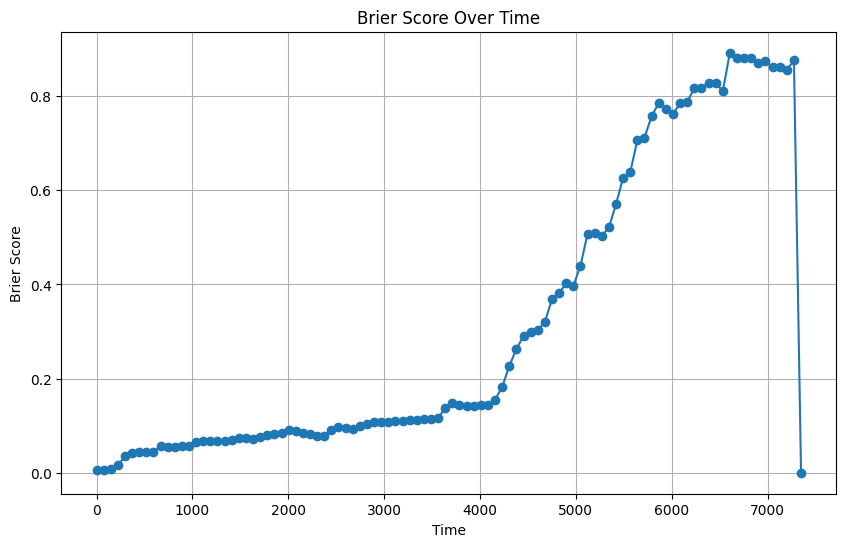

Integrated Brier Score (IBS) over the entire time range: 1.2958767684251768e-05


In [ ]:
import matplotlib.pyplot as plt

ibs = ev.brier_score(time_grid_np)

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(ibs.index, ibs.values, marker='o', linestyle='-')
plt.title('Brier Score Over Time')
plt.xlabel('Time')
plt.ylabel('Brier Score')
plt.grid(True)
plt.show()

# Print the last value of the series as the overall Integrated Brier Score
print("Integrated Brier Score (IBS) over the entire time range:", ibs.iloc[-1])

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 14.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3670292fbd7c37e713503c039a1c04279fe78e7b7d8a87edf0919d2715d148b7
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


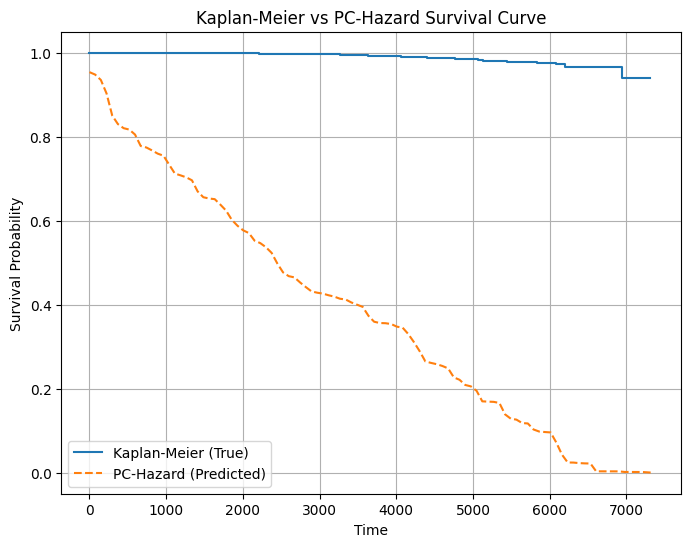

In [ ]:
# ============================================
# KAPLAN-MEIER vs PC-HAZARD SURVIVAL COMPARISON
# ============================================

import numpy as np
import torch
import matplotlib.pyplot as plt
!pip install lifelines
from lifelines import KaplanMeierFitter

# --------------------------------------------
# True data
# --------------------------------------------
durations_np = np.array(durations_test)
events_np = np.array(events_test)

# --------------------------------------------
# Kaplan-Meier (True Survival)
# --------------------------------------------
kmf = KaplanMeierFitter()
kmf.fit(durations_np, events_np, label="Kaplan-Meier (True)")

# --------------------------------------------
# PC-Hazard Predicted Survival
# --------------------------------------------
model.eval()

with torch.no_grad():
    x_test_tensor = x_test if torch.is_tensor(x_test) \
                    else torch.tensor(x_test, dtype=torch.float32)

    phi_test = model(x_test_tensor)
    surv_test = predict_survival(phi_test)

# Average predicted survival across individuals
mean_surv = surv_test.mean(dim=0).cpu().numpy()

# --------------------------------------------
# Plot
# --------------------------------------------
plt.figure(figsize=(8,6))

# True KM curve
kmf.plot_survival_function(ci_show=False)

# Predicted PC-Hazard curve
plt.plot(time_grid.cpu().numpy(), mean_surv, linestyle='--', label="PC-Hazard (Predicted)")

plt.title("Kaplan-Meier vs PC-Hazard Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()

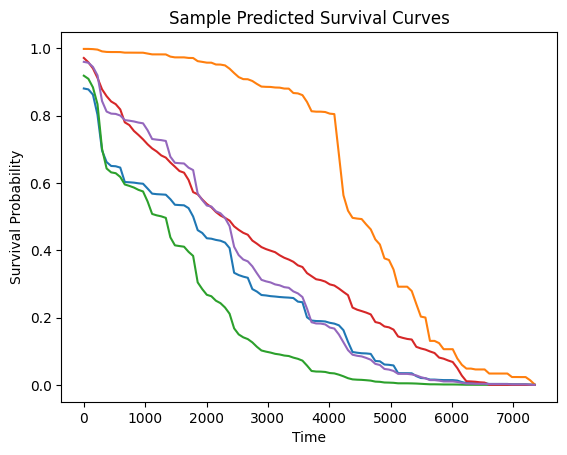

In [ ]:
plt.figure()

num_samples = 5
indices = np.random.choice(surv_test_np.shape[0], num_samples, replace=False)

for idx in indices:
    plt.plot(time_grid_np, surv_test_np[idx])

plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.title("Sample Predicted Survival Curves")
plt.show()

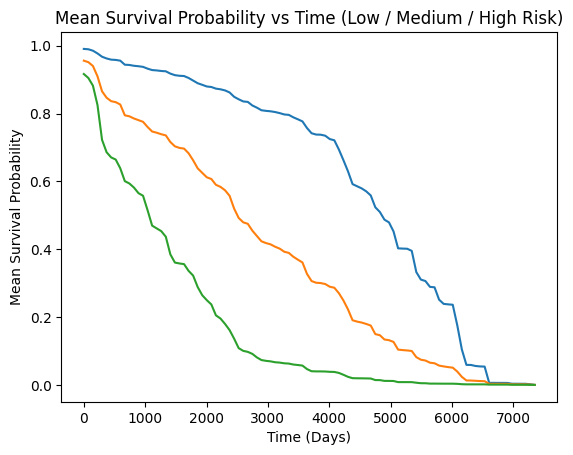

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert survival predictions safely
if hasattr(surv_test, "detach"):
    surv_test_np = surv_test.detach().cpu().numpy()
else:
    surv_test_np = surv_test

# Convert time grid
if hasattr(time_grid, "detach"):
    time_grid_np = time_grid.detach().cpu().numpy()
else:
    time_grid_np = time_grid

# Risk score (negative area under survival curve)
risk_scores = -np.sum(surv_test_np, axis=1)

# Tertile thresholds
low_thresh = np.percentile(risk_scores, 33)
high_thresh = np.percentile(risk_scores, 66)

# Risk groups
low_risk = risk_scores <= low_thresh
medium_risk = (risk_scores > low_thresh) & (risk_scores <= high_thresh)
high_risk = risk_scores > high_thresh

# Mean survival curves
mean_low = surv_test_np[low_risk].mean(axis=0)
mean_medium = surv_test_np[medium_risk].mean(axis=0)
mean_high = surv_test_np[high_risk].mean(axis=0)

plt.figure()

plt.plot(time_grid_np, mean_low)
plt.plot(time_grid_np, mean_medium)
plt.plot(time_grid_np, mean_high)

plt.xlabel("Time (Days)")
plt.ylabel("Mean Survival Probability")
plt.title("Mean Survival Probability vs Time (Low / Medium / High Risk)")
plt.show()